# Breast Cancer Dataset - Exploratory Data Analysis

## Load the dataset

In [1]:
# Importing Required libraries
from sklearn.datasets import load_breast_cancer
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
# Loading data sets
breast_cancer = load_breast_cancer()
df_cancer = pd.DataFrame(data=breast_cancer.data, columns=breast_cancer.feature_names)
df_cancer['target'] = breast_cancer.target
df_cancer.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


## 1. Data Loading and Exploration

**Q1.1** columns available - the 30 measured features plus target, listed below.

In [2]:
list(df_cancer.columns)

['mean radius',
 'mean texture',
 'mean perimeter',
 'mean area',
 'mean smoothness',
 'mean compactness',
 'mean concavity',
 'mean concave points',
 'mean symmetry',
 'mean fractal dimension',
 'radius error',
 'texture error',
 'perimeter error',
 'area error',
 'smoothness error',
 'compactness error',
 'concavity error',
 'concave points error',
 'symmetry error',
 'fractal dimension error',
 'worst radius',
 'worst texture',
 'worst perimeter',
 'worst area',
 'worst smoothness',
 'worst compactness',
 'worst concavity',
 'worst concave points',
 'worst symmetry',
 'worst fractal dimension',
 'target']

**Q1.2** shape of the dataset

In [3]:
df_cancer.shape

(569, 31)

569 rows, 31 columns (30 features + target).

**Q1.3** data types

In [4]:
df_cancer.info()

<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         569 non-null

all 30 features are float64 and target is int64, so everything is already numeric - no type conversion needed.

**Q1.4** summary stats for mean radius

In [5]:
df_cancer['mean radius'].describe()

count    569.000000
mean      14.127292
std        3.524049
min        6.981000
25%       11.700000
50%       13.370000
75%       15.780000
max       28.110000
Name: mean radius, dtype: float64

mean = 14.13, median = 13.37, std = 3.52. mean sitting above median already hints at a right skew (confirmed in the histogram below).

**Q1.5** missing values

In [6]:
df_cancer.isnull().sum().sum()

np.int64(0)

no missing values anywhere in the dataset.

## 2. Data Cleaning

**Q2.1** since there's nothing missing, no imputation/dropping needed here. In general I'd go with mean/median fill for small amounts of missing numeric data, or drop rows/columns if missingness is heavy.

**Q2.2** target labels

In [7]:
df_cancer['target'].value_counts()

target
1    357
0    212
Name: count, dtype: int64

0 = malignant, 1 = benign (sklearn's own encoding). only two clean values, 212 and 357, no weird entries.

## 3. Descriptive Statistics

**Q3.1** mean area & mean compactness

In [8]:
print('mean area -> mean: %.3f median: %.3f std: %.3f' % (
    df_cancer['mean area'].mean(), df_cancer['mean area'].median(), df_cancer['mean area'].std()))
print('mean compactness -> mean: %.5f median: %.5f std: %.5f' % (
    df_cancer['mean compactness'].mean(), df_cancer['mean compactness'].median(), df_cancer['mean compactness'].std()))

mean area -> mean: 654.889 median: 551.100 std: 351.914
mean compactness -> mean: 0.10434 median: 0.09263 std: 0.05281


mean area's mean is way above its median with a big std - right skewed, a handful of large tumors pulling the average up. mean compactness shows the same pattern on a smaller scale.

**Q3.2** histogram of mean radius

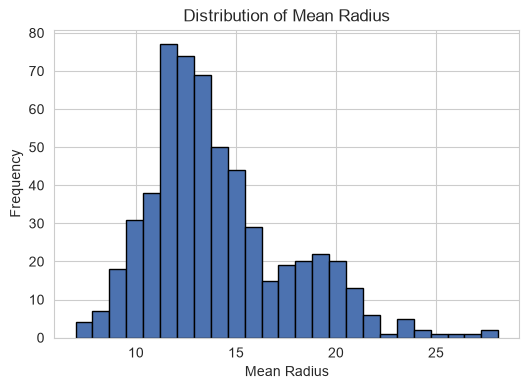

In [9]:
plt.figure(figsize=(6,4))
plt.hist(df_cancer['mean radius'], bins=25, color="#4C72B0", edgecolor="black")
plt.title("Distribution of Mean Radius")
plt.xlabel("Mean Radius")
plt.ylabel("Frequency")
plt.show()

right-skewed - most values bunch up between ~10-16 with a long tail out to 25-28.

**Q3.3** boxplot of mean texture

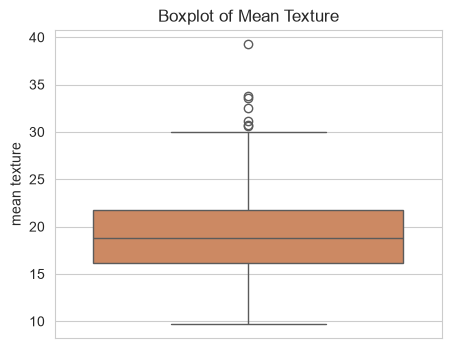

Q1: 16.17 Q3: 21.8 IQR: 5.629999999999999


In [10]:
plt.figure(figsize=(5,4))
sns.boxplot(y=df_cancer['mean texture'], color="#DD8452")
plt.title("Boxplot of Mean Texture")
plt.show()

q1 = df_cancer['mean texture'].quantile(0.25)
q3 = df_cancer['mean texture'].quantile(0.75)
iqr = q3 - q1
print('Q1:', q1, 'Q3:', q3, 'IQR:', iqr)

IQR is 5.63, and there are 7 points above the upper whisker - a few samples with unusually high texture. left them in since they could be real aggressive cases, not just noise.

**Q3.4** mean perimeter grouped by diagnosis

In [11]:
df_cancer.groupby('target')['mean perimeter'].mean()

target
0    115.365377
1     78.075406
Name: mean perimeter, dtype: float64

yes, big difference - malignant tumors average ~115.4 vs ~78.1 for benign, about 48% bigger.

## 4. Data Visualization

**Q4.1** benign vs malignant counts

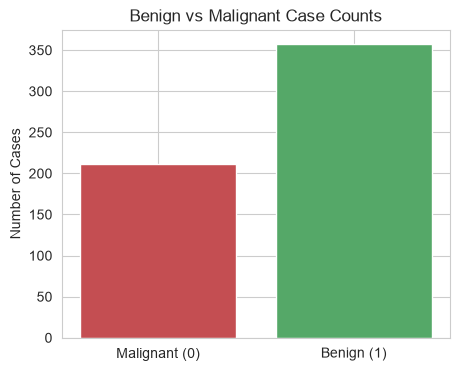

In [12]:
counts = df_cancer['target'].value_counts().sort_index()
plt.figure(figsize=(5,4))
plt.bar(["Malignant (0)", "Benign (1)"], counts.values, color=["#C44E52", "#55A868"])
plt.title("Benign vs Malignant Case Counts")
plt.ylabel("Number of Cases")
plt.show()

- The dataset contains **357 benign** and **212 malignant** cases, giving a **moderate class imbalance (~63% vs. 37%)**. This isn't severe, but it's something to keep in mind when training and evaluating the model.

**Q4.2** mean radius vs mean texture scatter

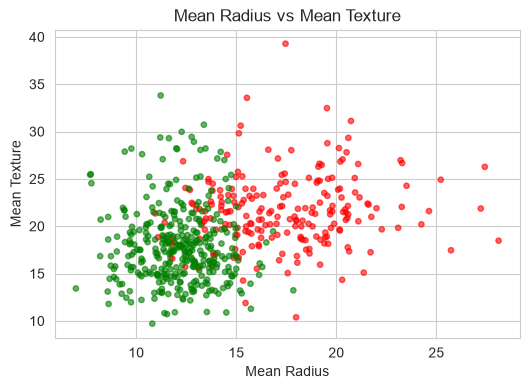

In [20]:
colors = df_cancer['target'].map({0: "red", 1: "green"})
plt.figure(figsize=(6,4))
plt.scatter(df_cancer['mean radius'], df_cancer['mean texture'], c=colors, alpha=0.6, s=15)
plt.xlabel("Mean Radius")
plt.ylabel("Mean Texture")
plt.title("Mean Radius vs Mean Texture")
plt.show()

- Malignant cases (red) tend to have **higher radius values**, while benign cases (green) are mostly clustered at **lower radius values**.
- **Texture alone** does not clearly separate the two classes, but when combined with **radius**, two fairly distinct groups begin to emerge.

**Q4.3** pairplot

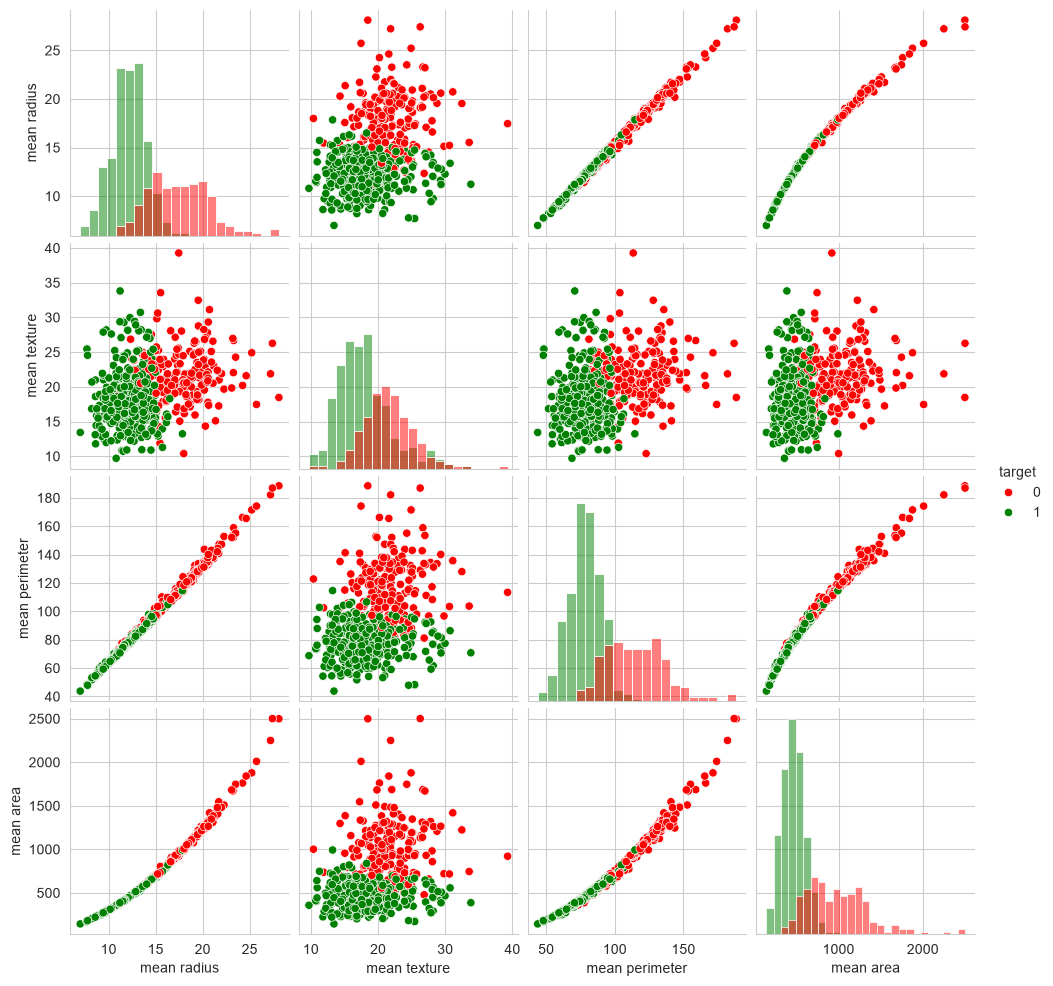

In [14]:
subset_cols = ['mean radius', 'mean texture', 'mean perimeter', 'mean area', 'target']

sns.pairplot(
    df_cancer[subset_cols],
    hue='target',
    diag_kind='hist',
    palette={0: 'red', 1: 'green'}
)

plt.show()

- I kept the plot to **just four features** so it's easier to read without feeling too crowded.
- **Radius, perimeter, and area** are almost perfectly correlated, which is expected since they're all closely related measurements of size.
- Across these features, the **malignant (red)** and **benign (green)** cases form fairly distinct clusters.
- **Texture** shows much more overlap between the two classes, so it isn't as effective on its own for separating them.

**Q4.4** correlation heatmap

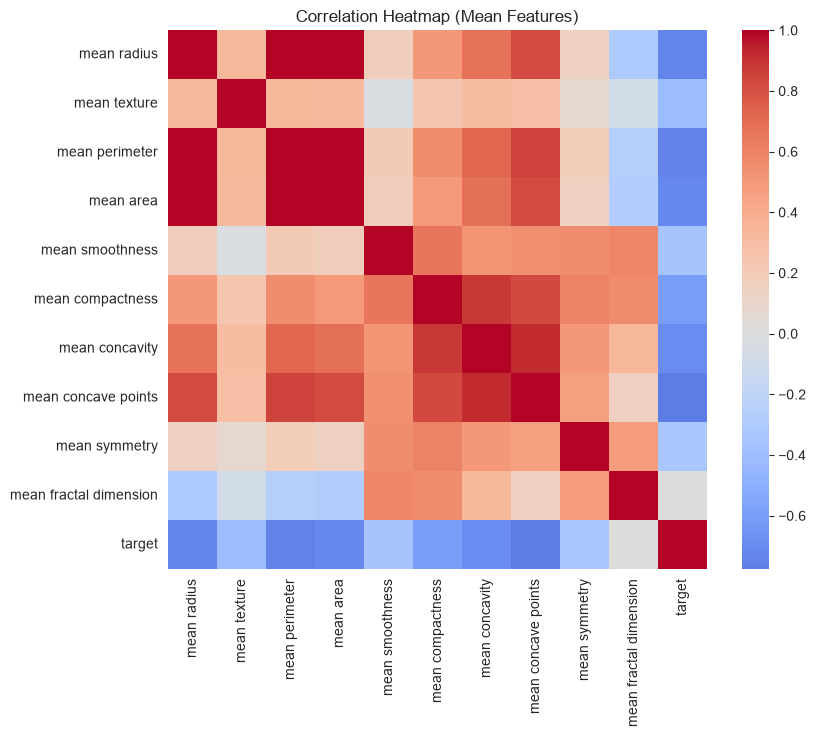

In [15]:
mean_cols = [c for c in df_cancer.columns if c.startswith("mean")] + ['target']
plt.figure(figsize=(9,7))
corr = df_cancer[mean_cols].corr()
sns.heatmap(corr, cmap="coolwarm", center=0, square=True)
plt.title("Correlation Heatmap (Mean Features)")
plt.show()

- The features most strongly related to the target are **worst concave points** (-0.79), **worst perimeter** (-0.78), **mean concave points** (-0.78), **worst radius** (-0.78), and **mean perimeter** (-0.74).
- **Radius, perimeter, and area** are almost perfectly correlated (correlation > 0.99), which means they provide almost the same information. For a linear model, it may be better to keep only one of these features. 

## 5. Feature Engineering

**Q5.1** area_to_perimeter_ratio

In [16]:
df_cancer['area_to_perimeter_ratio'] = df_cancer['mean area'] / df_cancer['mean perimeter']
df_cancer.groupby('target')['area_to_perimeter_ratio'].mean()

target
0    8.207072
1    5.800921
Name: area_to_perimeter_ratio, dtype: float64

- The **area-to-perimeter ratio** is higher on average for **malignant tumors** (~8.21) than for **benign tumors** (~5.80).
- This suggests that malignant tumors tend to be **larger and have more irregular shapes**, making this ratio a useful feature for distinguishing between the two classes.

**Q5.2** does it help separability?

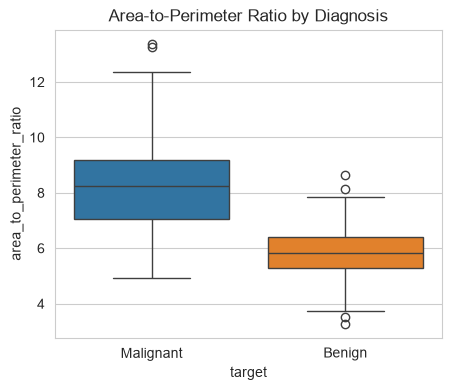

In [17]:
plt.figure(figsize=(5,4))
sns.boxplot(x='target', y='area_to_perimeter_ratio', data=df_cancer, hue='target', legend=False)
plt.xticks([0,1], ["Malignant","Benign"])
plt.title("Area-to-Perimeter Ratio by Diagnosis")
plt.show()

somewhat - malignant sits clearly higher with only some overlap in the middle, probably wouldn't beat mean area/perimeter individually but it condenses two correlated features into one.

**Q5.3** another derived feature

In [18]:
df_cancer['concavity_to_compactness_ratio'] = df_cancer['mean concavity'] / df_cancer['mean compactness']
df_cancer.groupby('target')['concavity_to_compactness_ratio'].mean()

target
0    1.090733
1    0.513215
Name: concavity_to_compactness_ratio, dtype: float64

malignant is roughly double to the benign ratio (1.09 vs 0.51) this suggests that malignant tumors have proportionally sharper concave dips rather than just being smooth/compact.

## 6. Conclusion

### Key Findings
- No missing data; all features are numeric.
- Radius, perimeter, and area are highly correlated.
- Concave points and size-related features best separate malignant vs. benign cases.
- Several features are right-skewed.
- Moderate class imbalance: **63% benign**, **37% malignant**.

### Most Important Features
- Worst concave points
- Worst perimeter
- Mean concave points
- Worst radius
- Mean perimeter
- Engineered ratio features also show good class separation.

### Recommendations
- Since some features are highly correlated, I would try a **tree-based model** like Random Forest, as it can handle correlated features well.
- I would also keep the **class imbalance** in mind while training the model so that it does not become biased toward the benign class.
- Finally, I would pay more attention to **recall for the malignant class**, because correctly identifying cancer cases is more important than avoiding a few false alarms.